In [301]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [302]:
# Load dataset
df = pd.read_csv('aug_train.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## **EDA PART**

In [303]:
# ===== DATA ANALYSIS =====
print("Shape:", df.shape)
print("=======================================================")
print("\nColumn Types:\n", df.dtypes)
print("=======================================================")
print("\nMissing Values:\n", df.isnull().sum())
print("=======================================================")
print("\nDuplicated Rows:", df.duplicated().sum())
print("=======================================================")
print("\nBasic Stats:\n", df.describe())

Shape: (19158, 14)

Column Types:
 enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

Missing Values:
 enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

Duplicate

### **Target variable distribution**


/tmp/ipykernel_802/2792195020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df, palette='Blues')


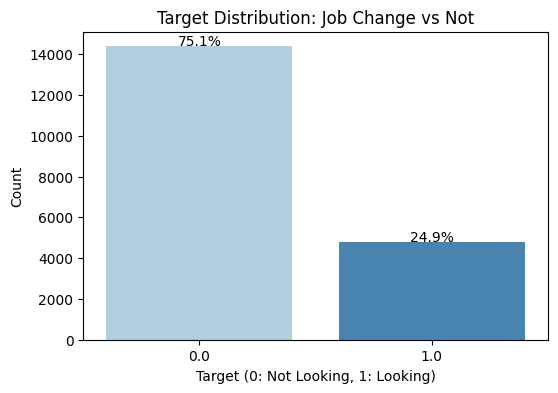

Class Balance:
 target
0.0    0.75
1.0    0.25
Name: proportion, dtype: float64


In [304]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df, palette='Blues')
plt.title("Target Distribution: Job Change vs Not")
plt.xlabel("Target (0: Not Looking, 1: Looking)")
plt.ylabel("Count")

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height() + 50), ha='center')
plt.show()

print("Class Balance:\n", df['target'].value_counts(normalize=True).round(2))

## **Missing values visualization**


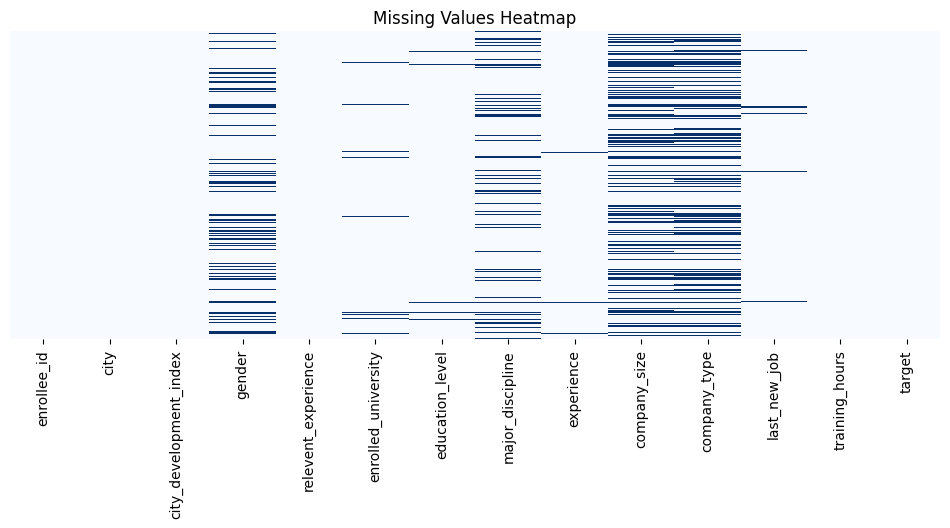

Missing Values %:
 company_type           32.05
company_size           30.99
gender                 23.53
major_discipline       14.68
education_level         2.40
last_new_job            2.21
enrolled_university     2.01
experience              0.34
dtype: float64


In [305]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='Blues', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

# Missing percentage per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
print("Missing Values %:\n", missing_pct)

## **Distribution of categorical columns**

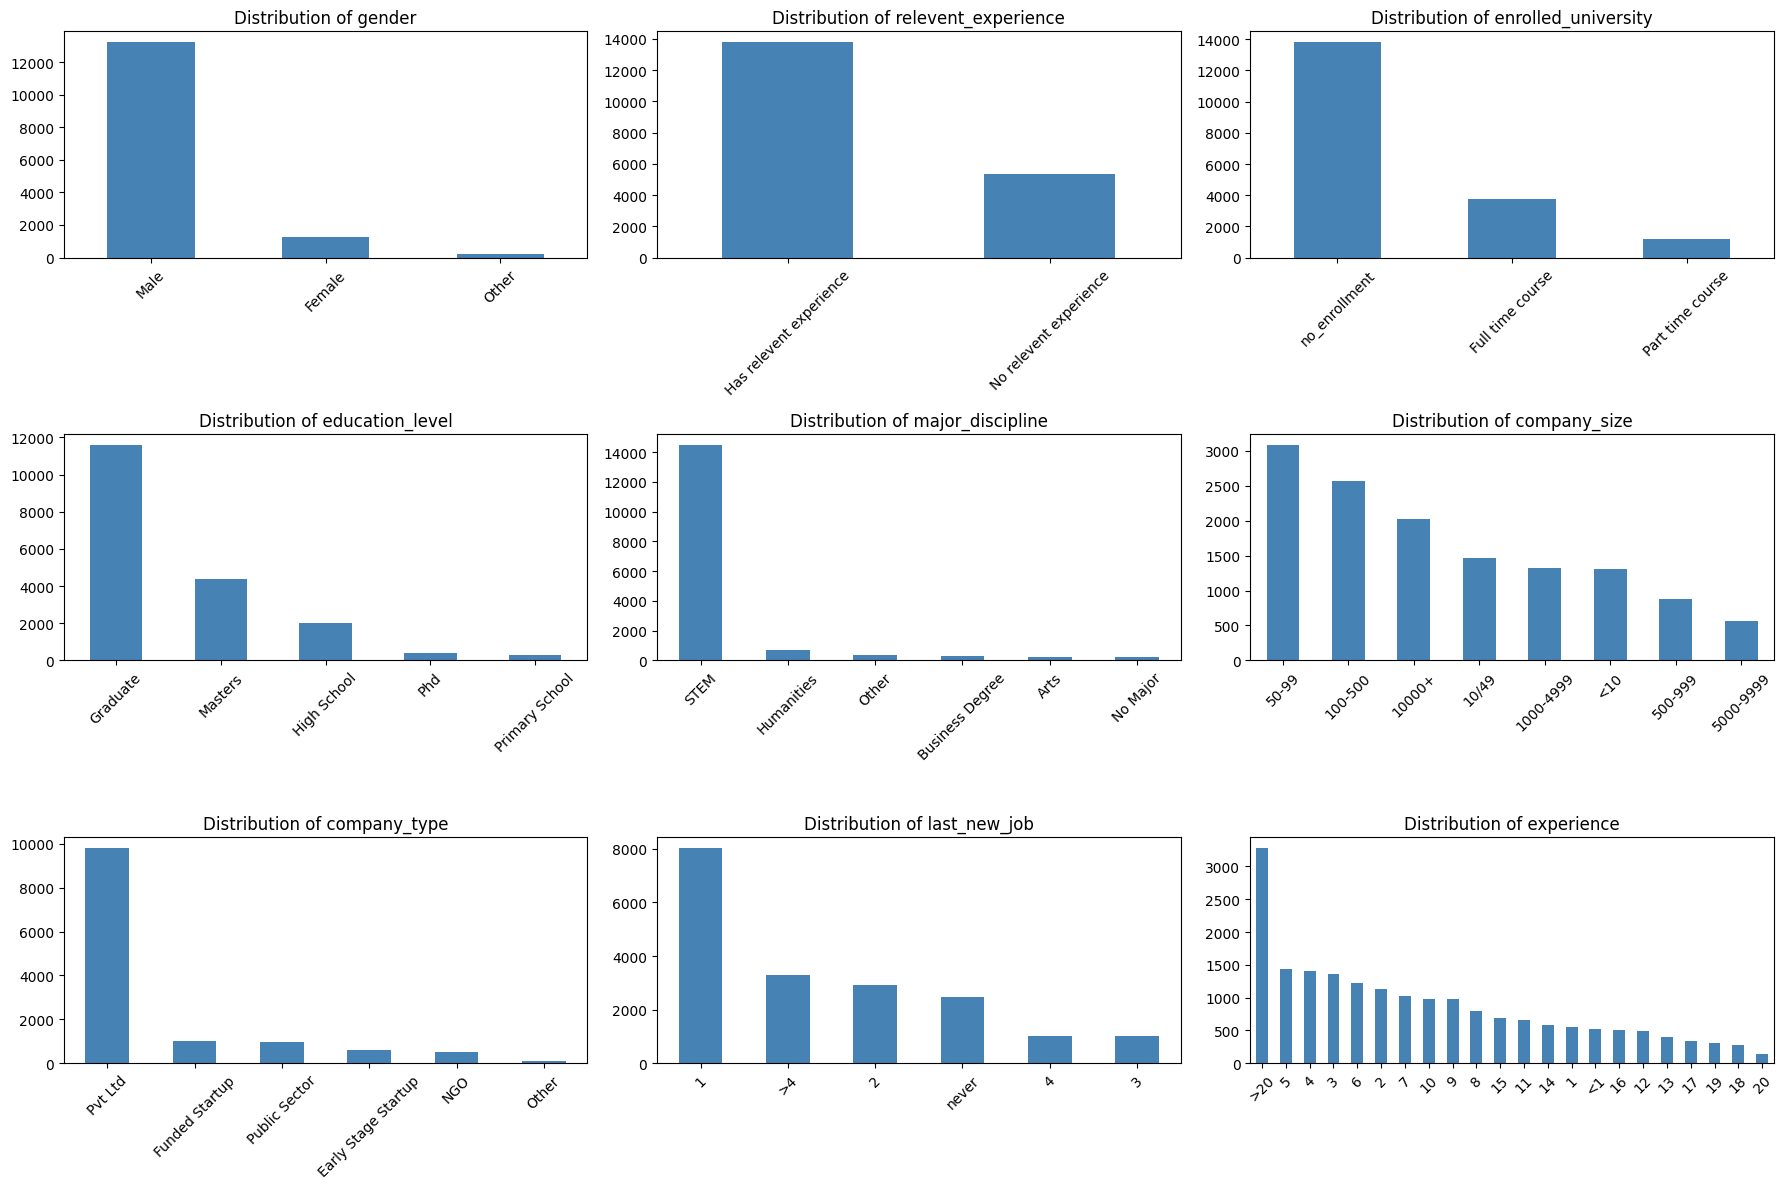

In [306]:
cat_cols = ['gender', 'relevent_experience', 'enrolled_university',
            'education_level', 'major_discipline', 'company_size',
            'company_type', 'last_new_job', 'experience']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## **Each categorical feature vs target**

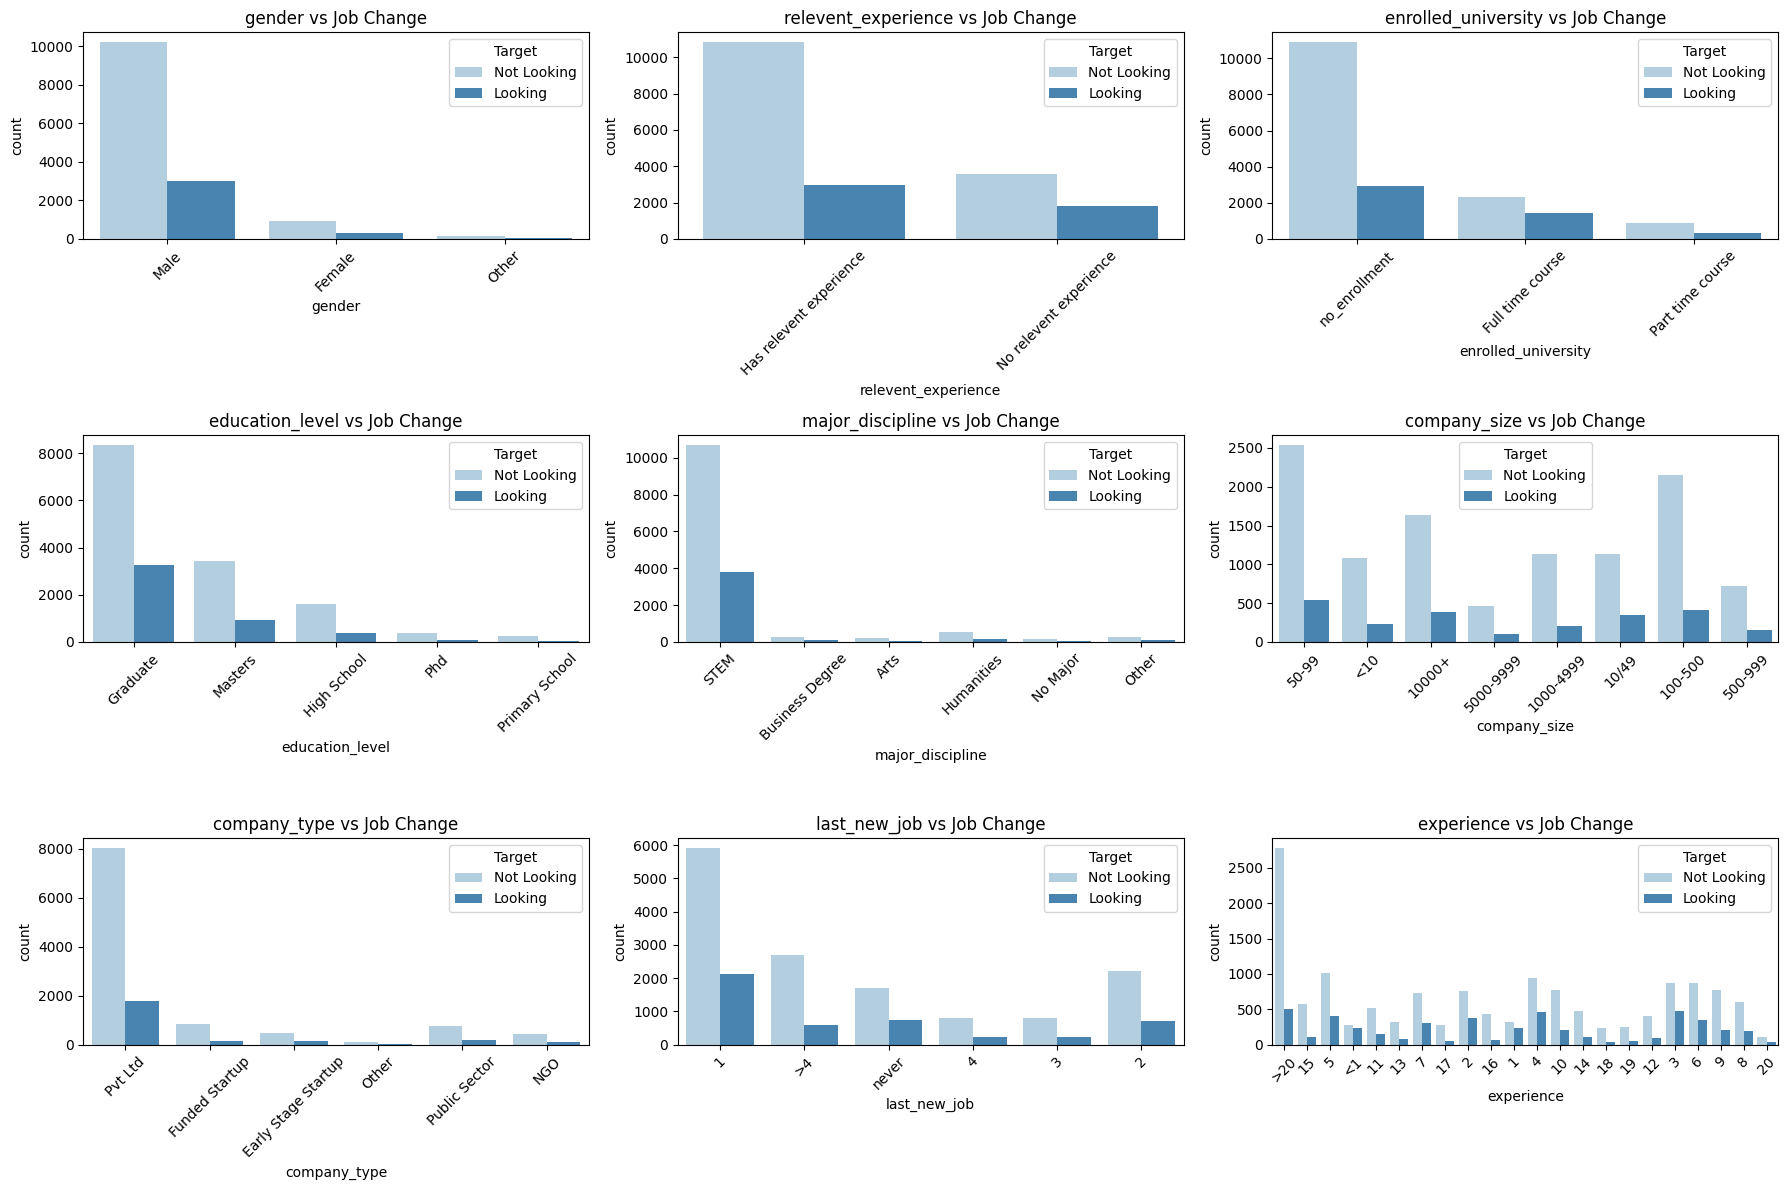

In [307]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='target', data=df, ax=axes[i], palette='Blues')
    axes[i].set_title(f'{col} vs Job Change')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Target', labels=['Not Looking', 'Looking'])

plt.tight_layout()
plt.show()

## **Numerical columns distribution**


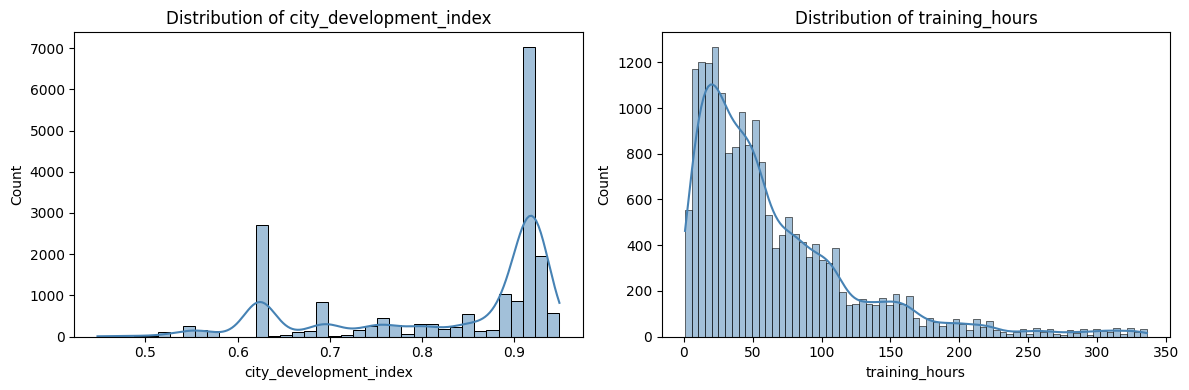

In [308]:
num_cols = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## **Correlation heatmap**

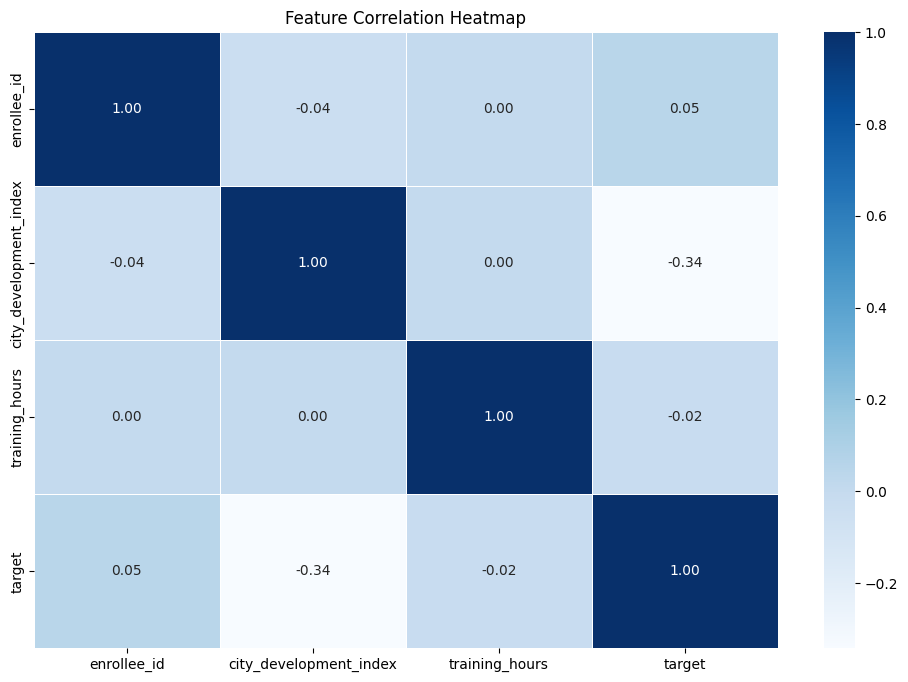

In [309]:
# Correlation heatmap - numeric columns only
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## **Handling Outliers in numerical columns**


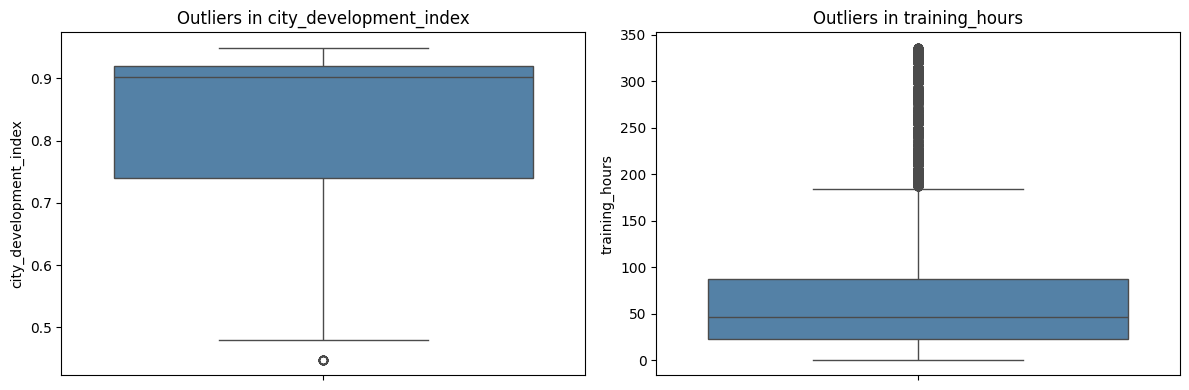

In [310]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

In [311]:
# ===== Remove Outliers from training_hours =====
q1 = df['training_hours'].quantile(0.25)
q3 = df['training_hours'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

before = df.shape[0]
df = df[df['training_hours'] <= upper]
after = df.shape[0]

print(f"Rows removed: {before - after}")
print(f"Shape after removing outliers: {df.shape}")

Rows removed: 984
Shape after removing outliers: (18174, 14)


**Handle missing values using fillna with mode (categrocal data)**

In [312]:

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Encode categorical variables using LabelEncoder
label_encoder = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

# Define features and target variable
X = df.drop(['enrollee_id', 'target','city', 'gender'], axis=1)
y = df['target']

/tmp/ipykernel_802/4230640391.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [313]:
# Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [314]:
# ===== Feature Scaling =====
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(" Scaling done — X_train shape:", X_train.shape)

 Scaling done — X_train shape: (12721, 10)


**logistic regression**

--- Logistic Regression ---
Accuracy: 0.71
Confusion Matrix:
 [[2986 1122]
 [ 477  868]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.73      0.79      4108
         1.0       0.44      0.65      0.52      1345

    accuracy                           0.71      5453
   macro avg       0.65      0.69      0.65      5453
weighted avg       0.76      0.71      0.72      5453



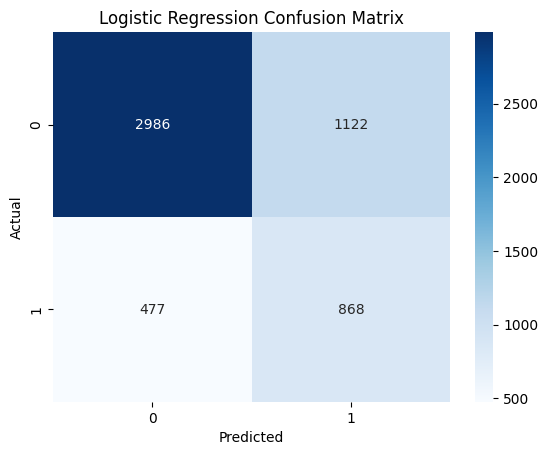

In [315]:
# Initialize and train Logistic Regression model
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train, y_train)

# Make predictions
y_pred_logreg = logreg.predict(X_test)

# Evaluate the model
print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

**KNN**

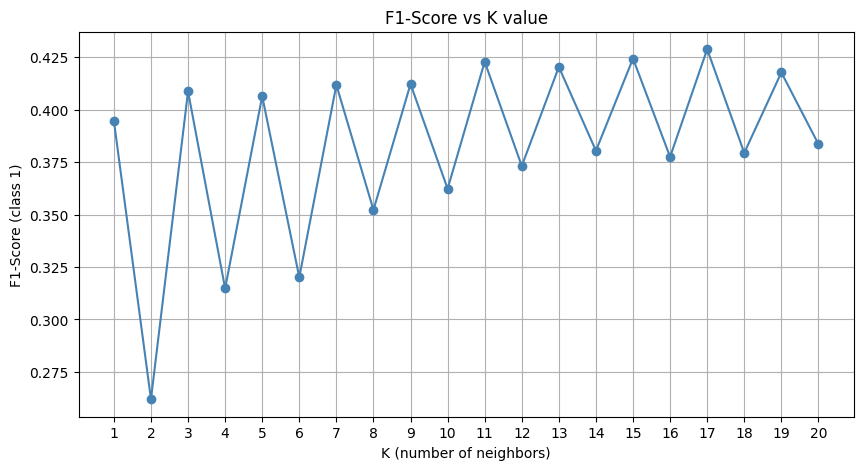

Best K: 17 with F1-Score: 0.43


In [316]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

k_values = range(1, 21)
f1_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred_temp))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, f1_scores, marker='o', color='steelblue')
plt.title("F1-Score vs K value")
plt.xlabel("K (number of neighbors)")
plt.ylabel("F1-Score (class 1)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[f1_scores.index(max(f1_scores))]
print(f"Best K: {best_k} with F1-Score: {max(f1_scores):.2f}")

--- K-Nearest Neighbors ---
Accuracy: 0.77
Confusion Matrix:
 [[3731  377]
 [ 875  470]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.91      0.86      4108
         1.0       0.55      0.35      0.43      1345

    accuracy                           0.77      5453
   macro avg       0.68      0.63      0.64      5453
weighted avg       0.75      0.77      0.75      5453



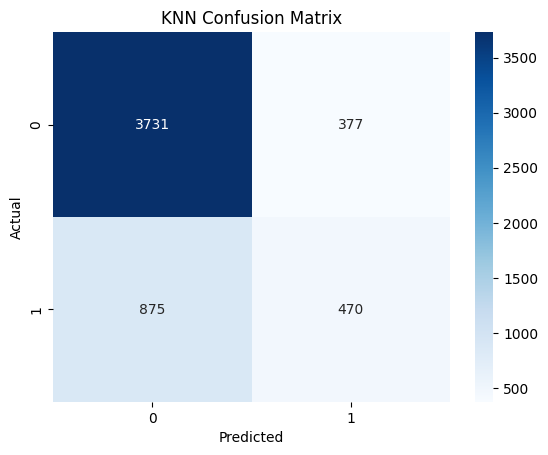

In [317]:
# Initialize and train KNN classifier
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test)

# Evaluate the model
print("--- K-Nearest Neighbors ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

**SVM**

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


--- Support Vector Machine ---
Accuracy: 0.25
Confusion Matrix:
 [[   2 4106]
 [   0 1345]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.00      0.00      4108
         1.0       0.25      1.00      0.40      1345

    accuracy                           0.25      5453
   macro avg       0.62      0.50      0.20      5453
weighted avg       0.81      0.25      0.10      5453



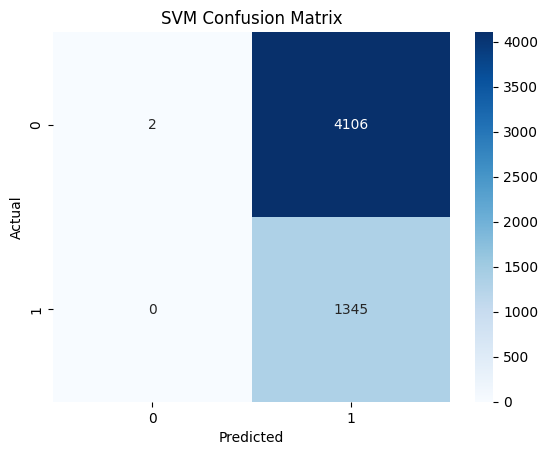

In [318]:
# Initialize and train SVM classifier (Simple & Fast)
svm_model = SVC(kernel='rbf', max_iter=2000, random_state=42, class_weight='balanced')
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
print("--- Support Vector Machine ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

**Decision Tree**

--- Decision Tree ---
Accuracy: 0.62
Confusion Matrix:
 [[2241 1867]
 [ 219 1126]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.55      0.68      4108
         1.0       0.38      0.84      0.52      1345

    accuracy                           0.62      5453
   macro avg       0.64      0.69      0.60      5453
weighted avg       0.78      0.62      0.64      5453



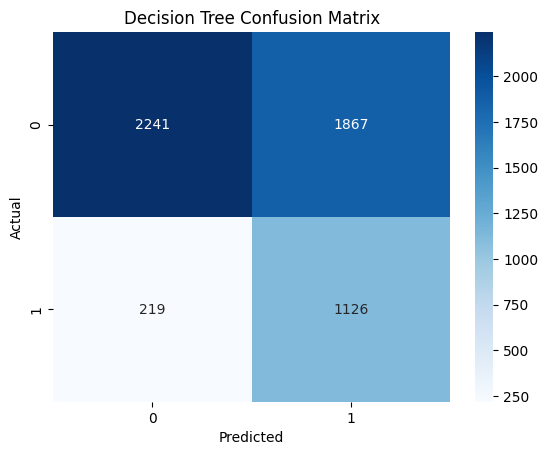

In [319]:
# Initialize and train Decision Tree classifier
dt_clf = DecisionTreeClassifier(criterion="gini", max_depth=3, class_weight='balanced')
dt_clf.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_clf.predict(X_test)

# Evaluate the model
print("--- Decision Tree ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

**Accuracy comparasion**

                 Model  Accuracy
0  Logistic Regression  0.706767
1        Decision Tree  0.617458
2                  KNN  0.770402
3                  SVM  0.247020


/tmp/ipykernel_802/1818827114.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='Blues_d')


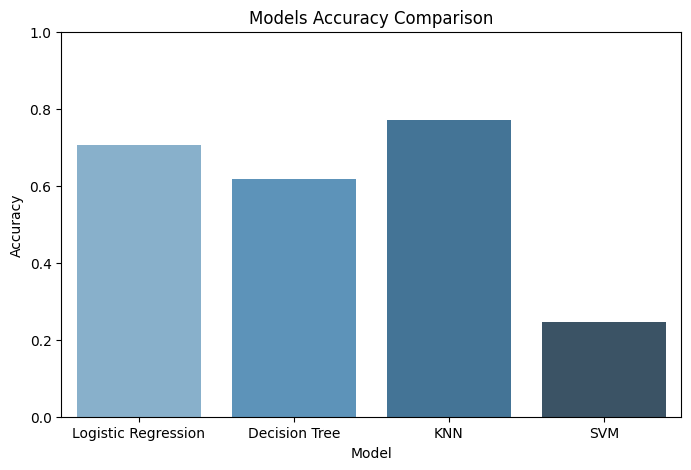

In [320]:
# Summary comparison of model accuracies
models_acc = {
    'Logistic Regression': accuracy_score(y_test, y_pred_logreg),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'SVM': accuracy_score(y_test, y_pred_svm),

}

acc_df = pd.DataFrame(list(models_acc.items()), columns=['Model', 'Accuracy'])
print(acc_df)

# Plot accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='Blues_d')
plt.title("Models Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

F1-Score (class 1) comparison:
Logistic Regression: 0.52
KNN:                 0.43
SVM:                 0.40
Decision Tree:       0.52


/tmp/ipykernel_802/3945590516.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='Blues_d')


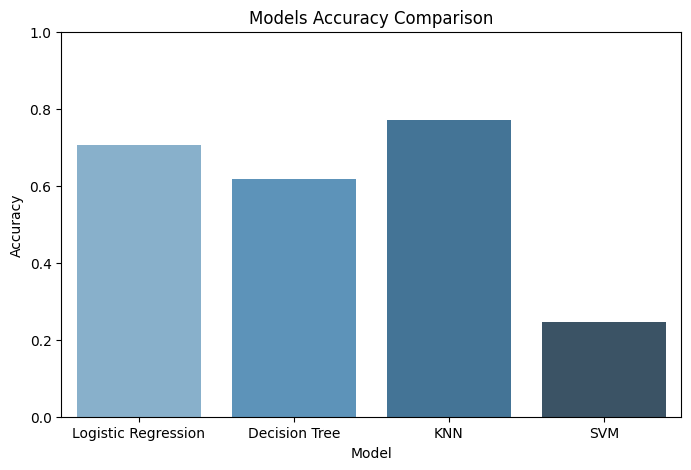

In [321]:
from sklearn.metrics import f1_score

print("F1-Score (class 1) comparison:")
print(f"Logistic Regression: {f1_score(y_test, y_pred_logreg):.2f}")
print(f"KNN:                 {f1_score(y_test, y_pred_knn):.2f}")
print(f"SVM:                 {f1_score(y_test, y_pred_svm):.2f}")
print(f"Decision Tree:       {f1_score(y_test, y_pred_dt):.2f}")

# Plot F1 comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='Blues_d')
plt.title("Models Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

**Business Insight 1: Feature Importance**

/tmp/ipykernel_802/2757397398.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="Blues_r")


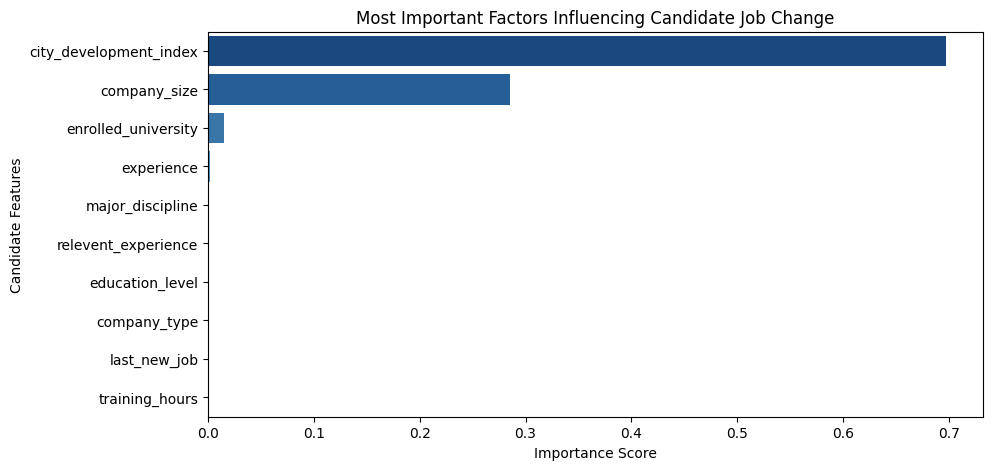

In [322]:

importances = dt_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette="Blues_r")
plt.title("Most Important Factors Influencing Candidate Job Change")
plt.xlabel("Importance Score")
plt.ylabel("Candidate Features")
plt.show()

**Business Insight 2: Candidate Trends**

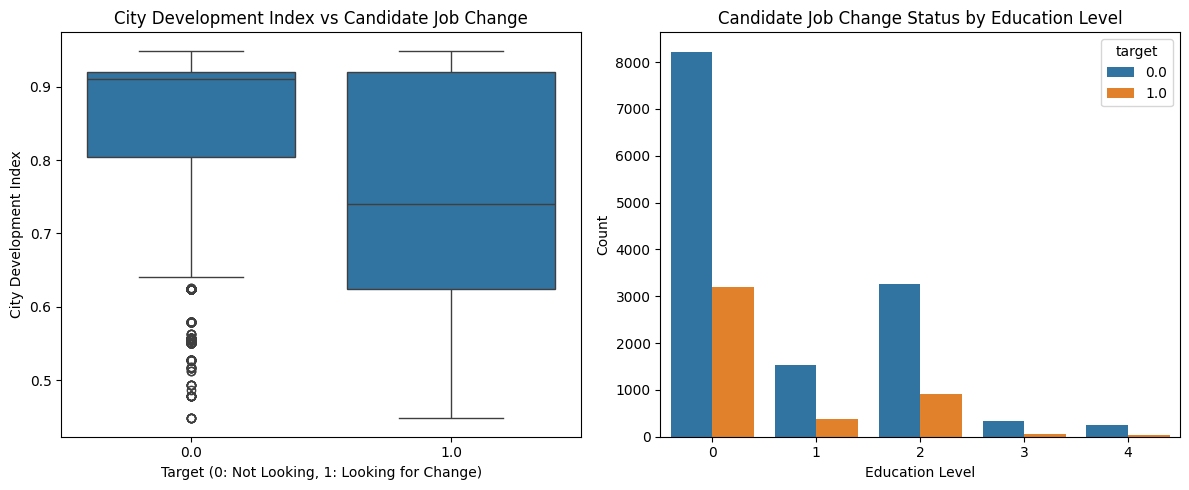

In [323]:
# Visualizing Business Trends
plt.figure(figsize=(12, 5))

# Graph 1: City Development Index vs Job Change (Target)
plt.subplot(1, 2, 1)
sns.boxplot(x='target', y='city_development_index', data=df)
plt.title("City Development Index vs Candidate Job Change")
plt.xlabel("Target (0: Not Looking, 1: Looking for Change)")
plt.ylabel("City Development Index")

# Graph 2: Education Level vs Job Change
plt.subplot(1, 2, 2)
sns.countplot(x='education_level', hue='target', data=df)
plt.title("Candidate Job Change Status by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## **Deployment part**

In [324]:
from sklearn.preprocessing import LabelEncoder
import joblib
import pandas as pd

df_fresh = pd.read_csv('aug_train.csv')

for col in df_fresh.columns:
    if df_fresh[col].isnull().sum() > 0:
        df_fresh[col].fillna(df_fresh[col].mode()[0], inplace=True)

encoders = {}
for col in df_fresh.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_fresh[col] = le.fit_transform(df_fresh[col])
    encoders[col] = le

joblib.dump(encoders, 'label_encoder.pkl')
joblib.dump(logreg, 'model.pkl')

print("Encoded columns:", list(encoders.keys()))
print("✅ Done!")

Encoded columns: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']
✅ Done!


/tmp/ipykernel_802/1843821089.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fresh[col].fillna(df_fresh[col].mode()[0], inplace=True)


In [325]:
from google.colab import files
files.download('label_encoder.pkl')
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>